# MORPHOLOGICAL OPERATORS

In [53]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [54]:
def load_img():
    blank_img = np.zeros((600, 600))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img, text='ABCDE', org=(50, 300), fontFace=font, fontScale=5, color=(255, 255, 255), thickness=20)
    return blank_img

In [55]:
def display_img(img):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')

### EROSION

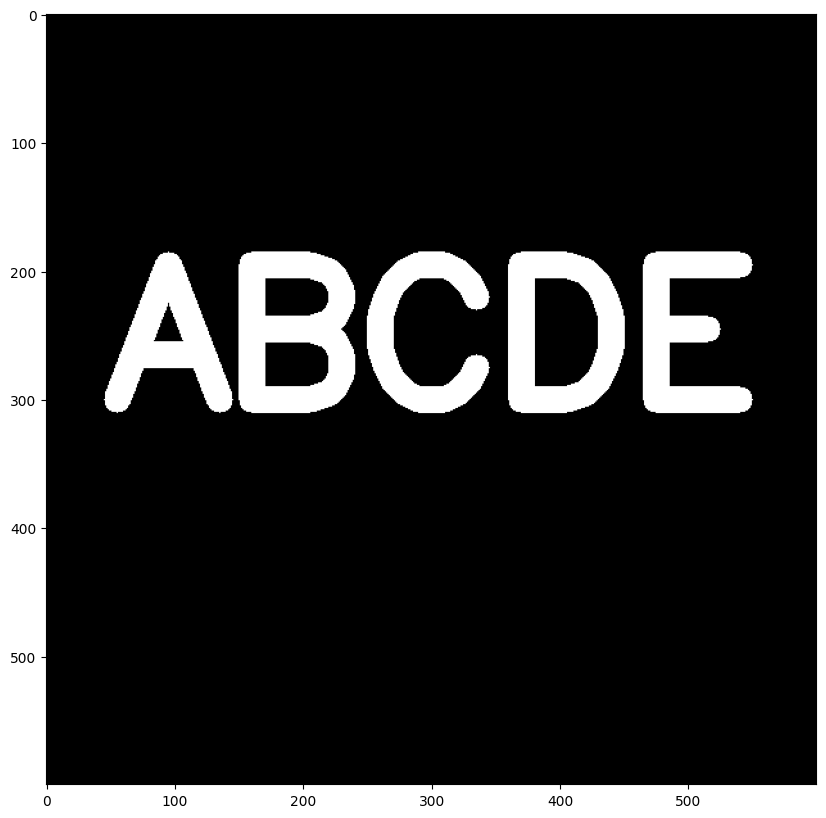

In [56]:
img = load_img()
display_img(img)

In [57]:
kernel = np.ones((5,5), dtype=(np.uint8))

In [58]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [59]:
# Erosion operation -> Removes pixels from the edges of objects, effectively shrinking them.
result = cv2.erode(img, kernel, iterations=3)
# By increasing the iterations, it keeps on removing the pixels from the edge.

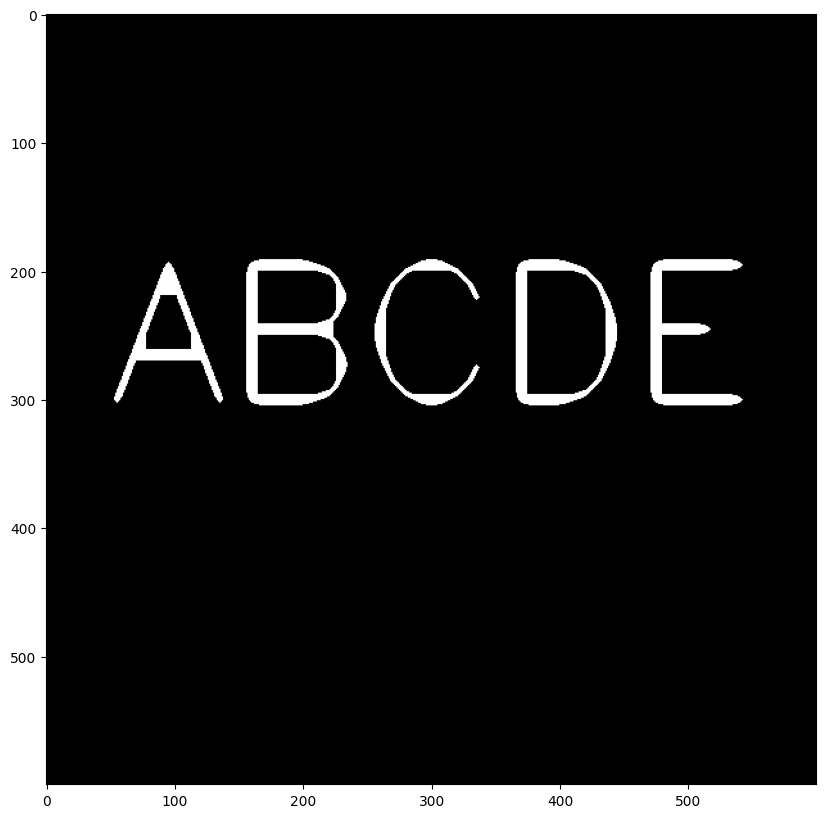

In [60]:
display_img(result)

### OPENING

In [61]:
img = load_img()

In [62]:
white_noise = np.random.randint(low=0, high=2, size=(600, 600))

In [63]:
white_noise

array([[0, 0, 0, ..., 1, 1, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 1, ..., 0, 1, 1],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 1, ..., 1, 0, 0]], shape=(600, 600), dtype=int32)

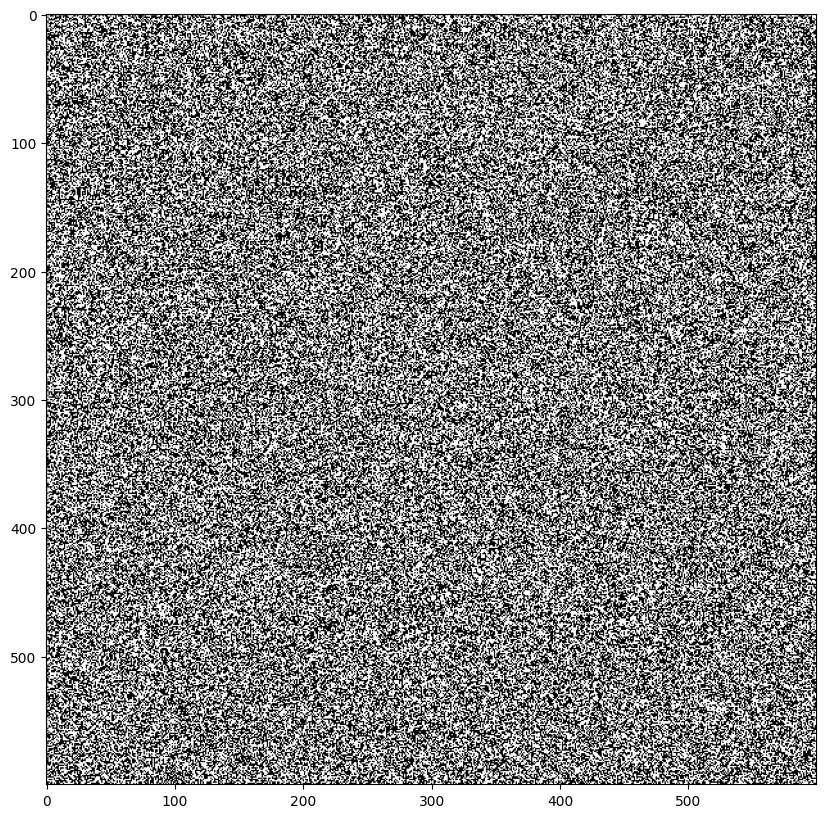

In [64]:
display_img(white_noise)

In [65]:
img.max()

np.float64(255.0)

In [66]:
white_noise = white_noise * 255

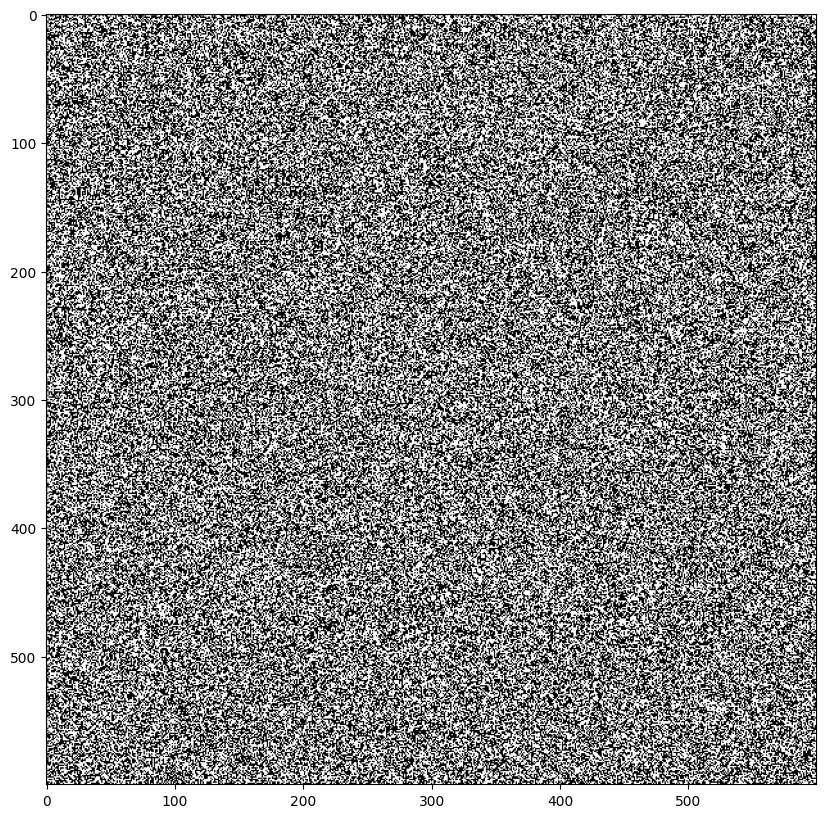

In [67]:
display_img(white_noise)

In [68]:
noise_img = white_noise + img

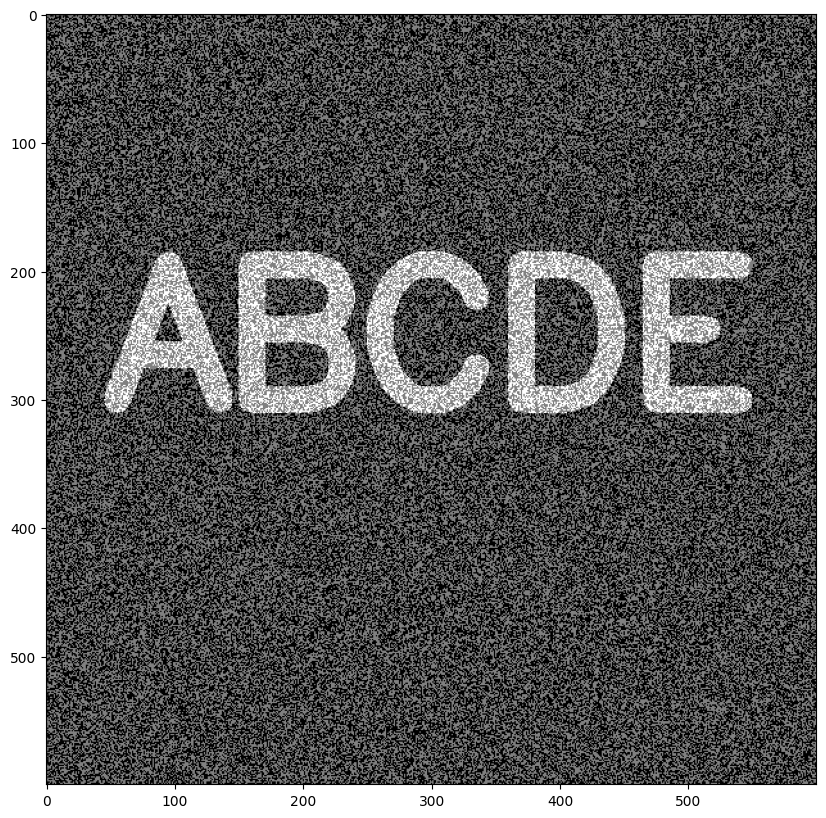

In [69]:
display_img(noise_img)

In [70]:
# OPENING -> A combination of erosion followed by dilation.
# DILATION -> Expands the boundaries of foreground pixels (typically white in a binary image). Exactly, the opposite of Erosion.
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

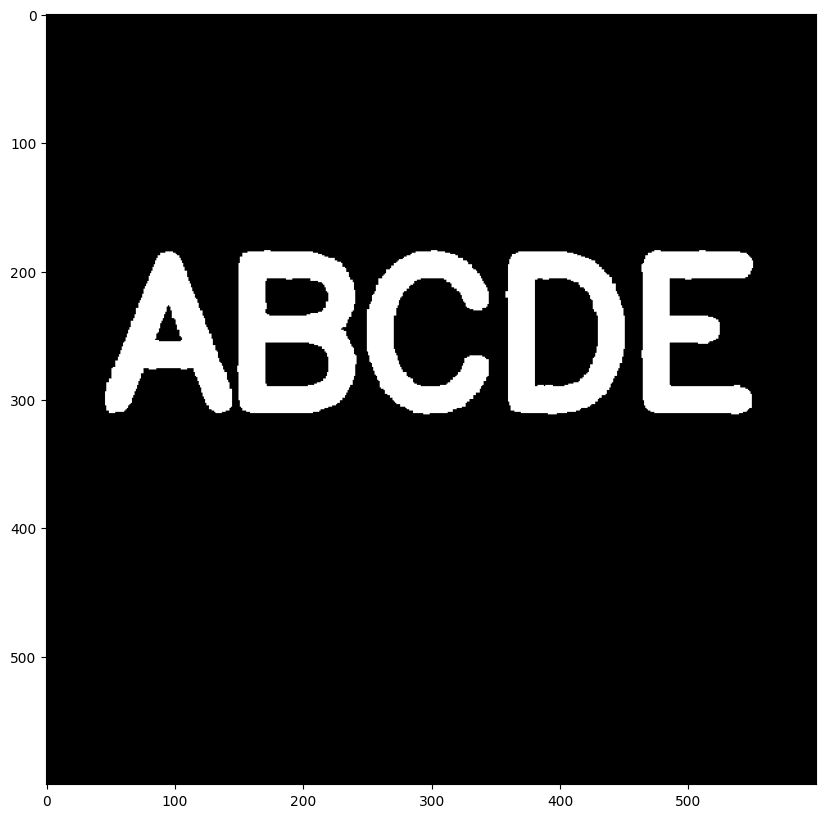

In [71]:
display_img(opening)

In [72]:
img = load_img()

In [73]:
black_noise = np.random.randint(low=0, high=2, size=(600, 600))

In [74]:
black_noise = black_noise * -255

In [75]:
black_noise

array([[   0,    0,    0, ..., -255,    0,    0],
       [-255, -255,    0, ...,    0,    0, -255],
       [   0,    0, -255, ...,    0, -255, -255],
       ...,
       [-255,    0,    0, ...,    0,    0,    0],
       [   0, -255, -255, ...,    0,    0, -255],
       [-255,    0,    0, ..., -255, -255,    0]],
      shape=(600, 600), dtype=int32)

In [76]:
black_noise_image = img + black_noise

In [77]:
black_noise_image

array([[   0.,    0.,    0., ..., -255.,    0.,    0.],
       [-255., -255.,    0., ...,    0.,    0., -255.],
       [   0.,    0., -255., ...,    0., -255., -255.],
       ...,
       [-255.,    0.,    0., ...,    0.,    0.,    0.],
       [   0., -255., -255., ...,    0.,    0., -255.],
       [-255.,    0.,    0., ..., -255., -255.,    0.]], shape=(600, 600))

In [78]:
black_noise_image[black_noise_image == -255] = 0

In [79]:
black_noise_image.min()

np.float64(0.0)

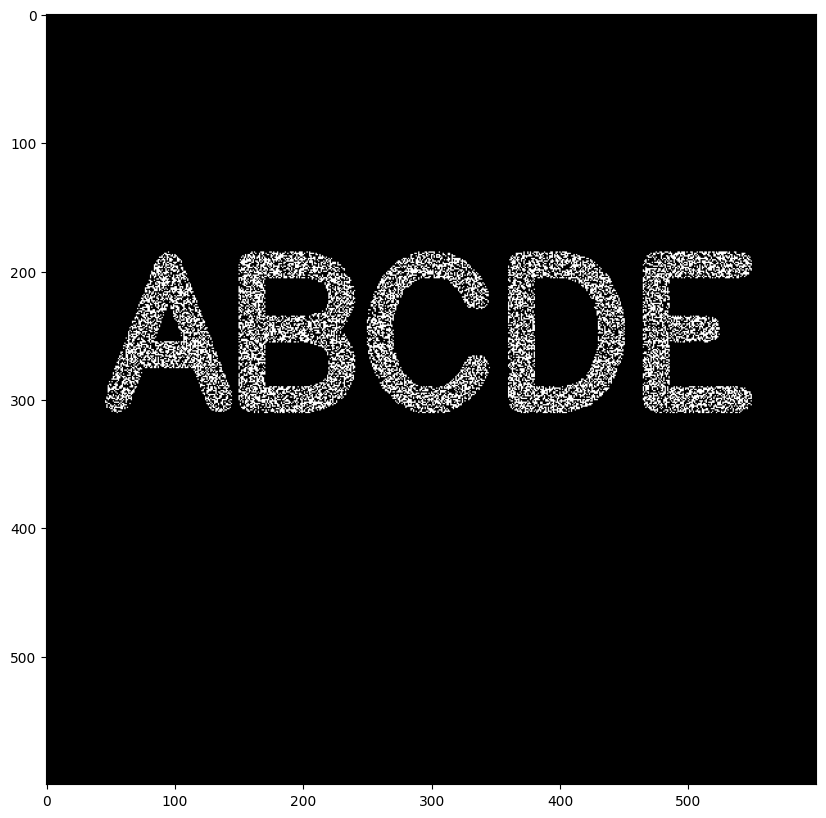

In [80]:
display_img(black_noise_image)

In [81]:
# In close operation, it removes small holes and gaps in objects in a binary image
closing = cv2.morphologyEx(black_noise_image, cv2.MORPH_CLOSE, kernel)

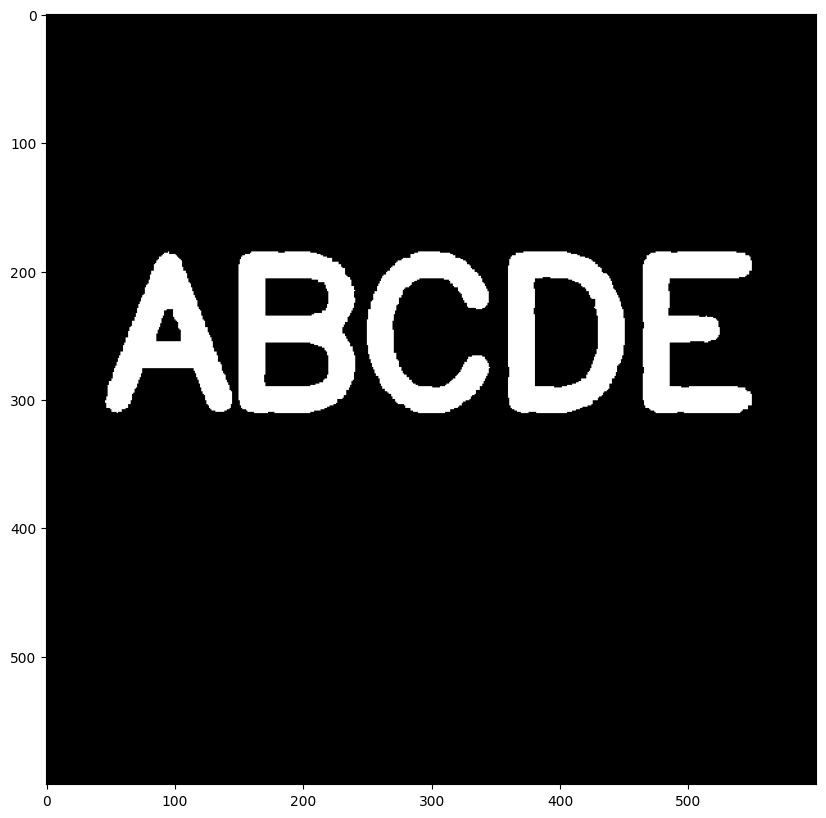

In [82]:
display_img(closing)

In [83]:
# GRADIENT -> It is used to highlight the edge of the image
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)

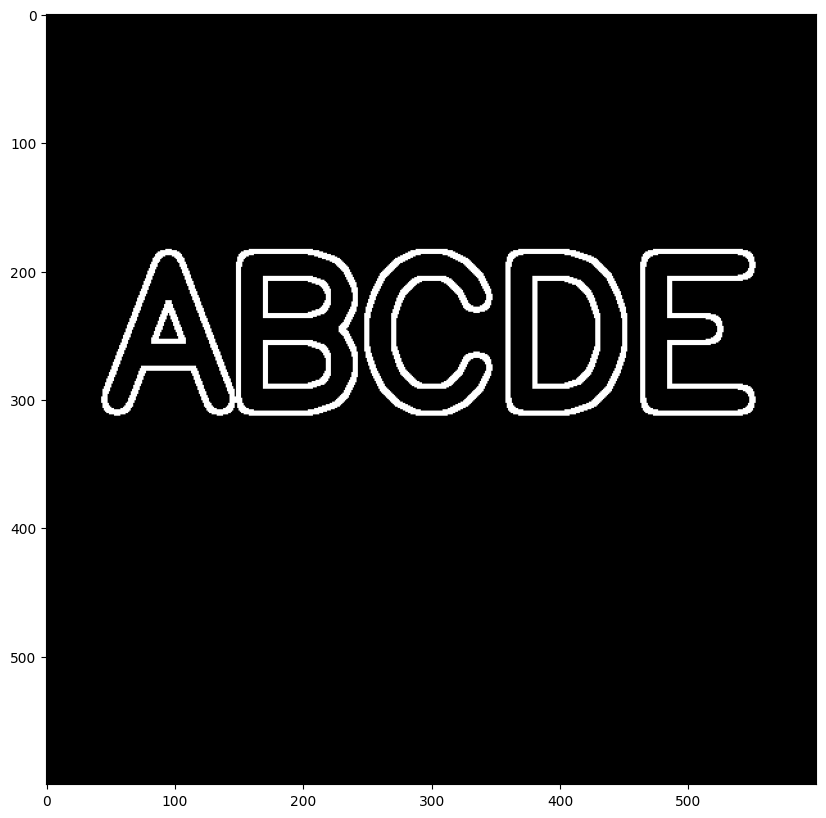

In [84]:
display_img(gradient)

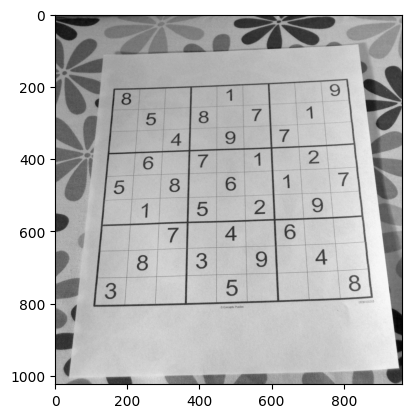

In [85]:
# Taking a another example
img = cv2.imread('../DATA/sudoku.jpg', 0)
plt.imshow(img, cmap='gray')

In [86]:
# Highlights the vertical outlines
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)

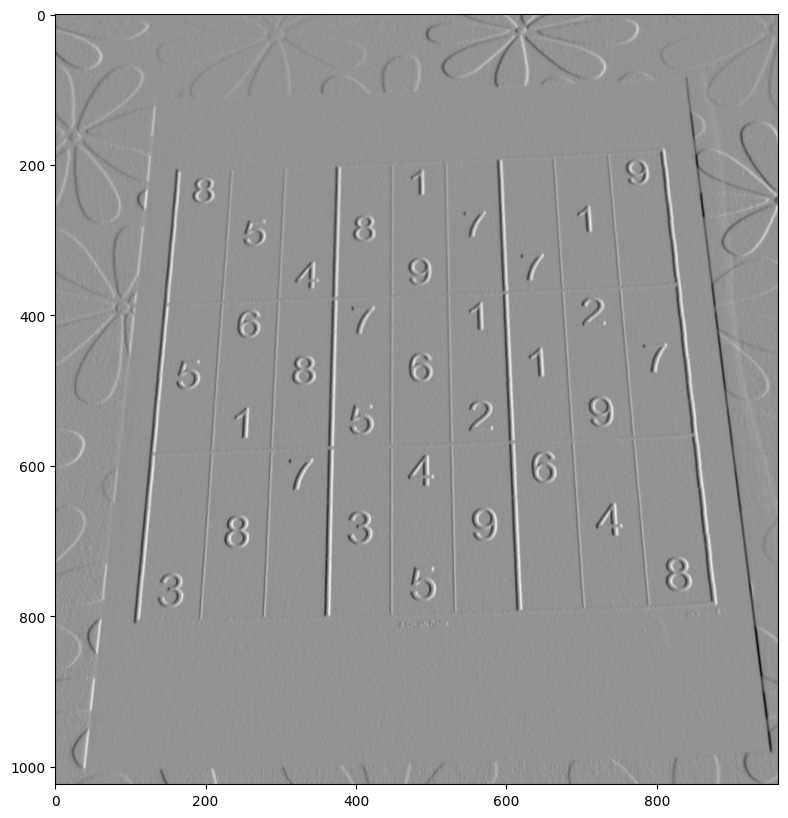

In [87]:
display_img(sobelx)

In [88]:
# Highlights the horizontal outlines
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

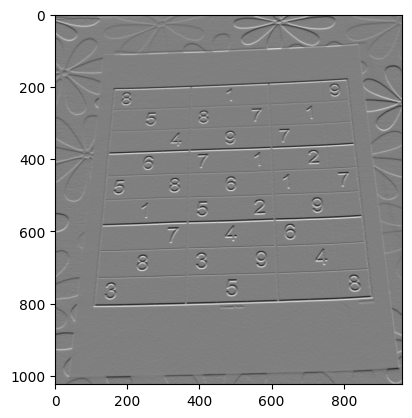

In [89]:
plt.imshow(sobely, cmap='gray')

In [92]:
# Laplacian -> A second-order derivative operator used in image processing that helps in detecting edges and defining the curvature of an image.
laplacian = cv2.Laplacian(img, cv2.CV_64F)

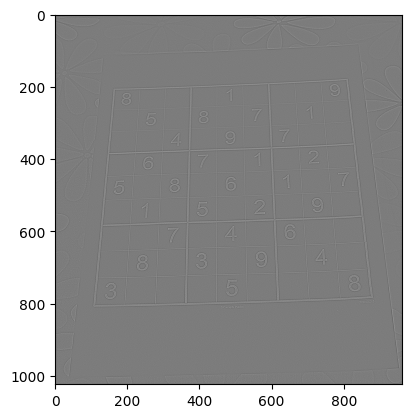

In [93]:
plt.imshow(laplacian, cmap = 'gray')

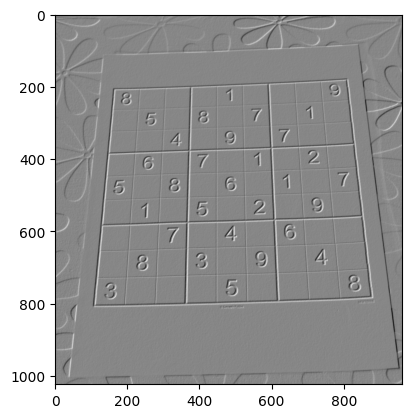

In [96]:
# Blend of sobelx and sobely
blended = cv2.addWeighted(src1=sobelx, alpha=0.6, src2=sobely, beta=0.4, gamma=0)
plt.imshow(blended, cmap = 'gray')

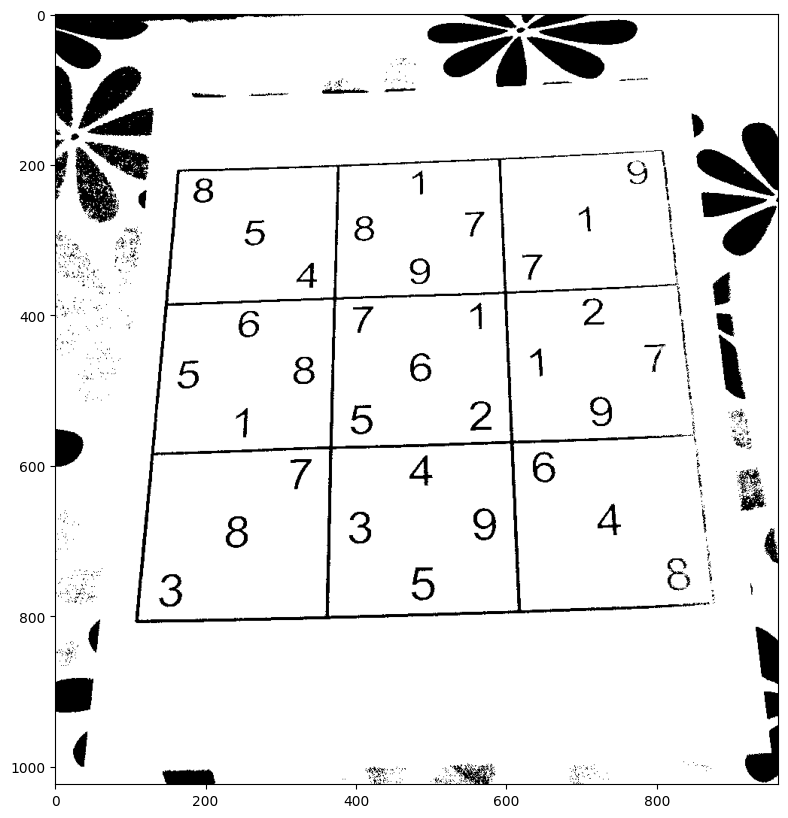

In [97]:
ret, th1 = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
display_img(th1)

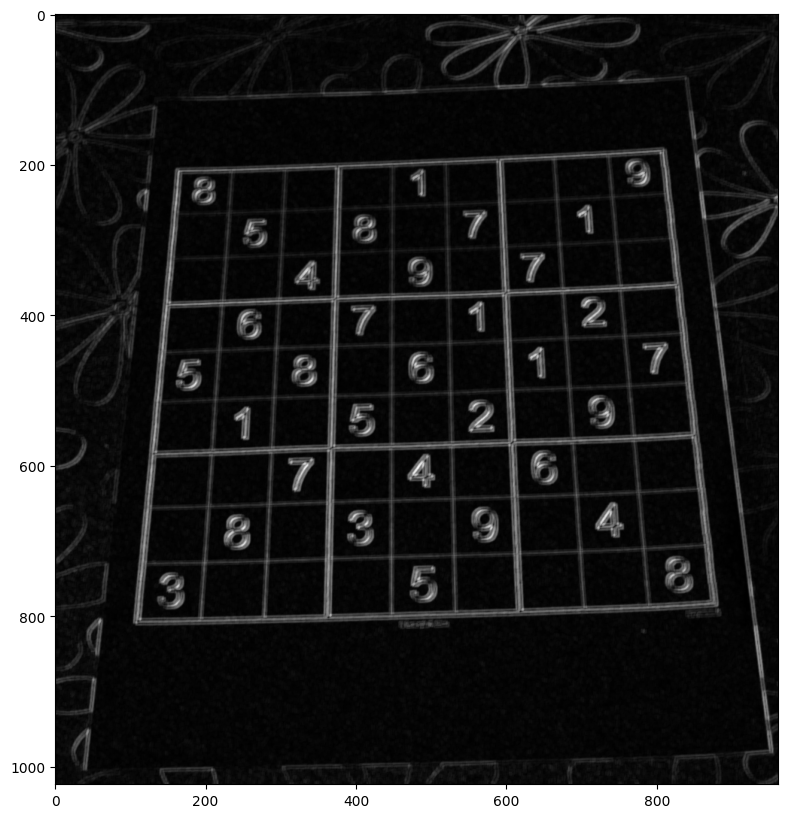

In [98]:
kernel = np.ones((4, 4), np.uint8)
gradient = cv2.morphologyEx(blended, cv2.MORPH_GRADIENT, kernel)
display_img(gradient)